## 07 — Tuning bayesiano (Optuna) con CV recursivo y burn-in

### Objetivo
 Buscar hiperparametros de XGBoost y LightGBM que minimicen el RMSE del forecast **multi-step recursivo**, usando una validacion cruzada temporal que corrige el problema de cold-start detectado en `05_validacion_ts.ipynb`: `count_lag_52w` y `media_historica` necesitan >=52 semanas reales de historia para no quedar en 0, y el `TimeSeriesSplit` original tenia folds tempranos con menos de eso.

### Que cambia respecto al pipeline original
1. CV con burn-in (`burn_in_splits`): solo se evaluan folds donde el train ya tiene >= `MIN_BURN_WEEKS` semanas reales.
2. Forecast recursivo vectorizado (`forecast_recursive_vectorized`): mismo resultado que `forecasting_recursivo` de los notebooks 04/05, pero mucho mas rapido — necesario porque Optuna llama esto cientos de veces.
3. `fillna_value=None`: cuando falta historia, se deja NaN en vez de 0. XGBoost y LightGBM manejan NaN nativamente y aprenden a tratarlo distinto de un cero real (una celda con historia real en 0 no es lo mismo que una celda sin historia).
4. Se quitan `semana_global` y `año` de las features: son indices de tendencia sin cota superior, y un arbol no puede extrapolar mas alla del maximo valor visto en train — en el holdout (siempre semanas futuras) ese split queda "congelado". Puedes reactivarlos con `DROP_TREND_FEATURES = False` si prefieres comparar con/sin.
### Importante sobre el numero de folds
Con ~62 semanas en dev y un burn-in de 52 semanas, solo caben 1-2 folds de 4 semanas. Es un limite real de cuantos datos tienes, no un bug. Preferible pocos folds comparables que 5 folds sesgados. Si quieres mas folds, baja `MIN_BURN_WEEKS` (p.ej. a 16, que es lo que necesita `rolling_mean_12w`) a costa de que `count_lag_52w`/`media_historica` sigan poco informados en esos folds — en ese caso considera sacarlos de `feature_cols` directamente.


In [40]:
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import optuna
from optuna.samplers import TPESampler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib

sys.path.append(str(Path.cwd()))
from forecast_utils import forecast_recursive_vectorized, burn_in_splits, rmse, mae, poisson_deviance

optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_DIR = Path("/Users/guillermo/Downloads/TA_IA_Aplicada/Data")
OUT_DIR = DATA_DIR.parent / "Modelado" / "optuna"
OUT_DIR.mkdir(parents=True, exist_ok=True)



In [41]:
# Configuracion
SEMANA_HOLDOUT_INICIO = 63     # igual que en 03/04/05
MIN_BURN_WEEKS = 52            # semanas reales minimas antes del primer fold de test
TEST_WEEKS_POR_FOLD = 4
FILLNA_VALUE = None            # None = deja NaN (recomendado); 0.0 = replica el pipeline original
DROP_TREND_FEATURES = True     # quita semana_global y año de las features
N_TRIALS_XGB = 60
N_TRIALS_LGBM = 60
RANDOM_STATE = 42

In [42]:
# Carga y split dev / holdout (identico a 03/04/05)
df = pd.read_csv(DATA_DIR / "df_features.csv")
df_dev = df[df["semana_global"] < SEMANA_HOLDOUT_INICIO].copy()
df_holdout = df[df["semana_global"] >= SEMANA_HOLDOUT_INICIO].copy()

turno_cols = [c for c in df_dev.columns if c.startswith("turno_")]
df_dev["turno_hecho"] = df_dev[turno_cols].idxmax(axis=1).str.replace("turno_", "")
df_holdout["turno_hecho"] = df_holdout[turno_cols].idxmax(axis=1).str.replace("turno_", "")

print(f"Dev: {df_dev.shape[0]} filas | Holdout: {df_holdout.shape[0]} filas")

Dev: 10664 filas | Holdout: 2064 filas


In [43]:
# Definicion de features (ver nota sobre DROP_TREND_FEATURES arriba)
feature_cols_num = [
    "semana_del_año_sin", "semana_del_año_cos", "mes_sin", "mes_cos",
    "semana_con_festivo",
    "count_lag_1w", "count_lag_2w", "count_lag_4w", "count_lag_8w", "count_lag_52w",
    "rolling_mean_4w", "rolling_mean_8w", "rolling_mean_12w",
    "rolling_std_4w", "rolling_std_8w",
    "media_historica",
    "distrito_id", "iso_week", "mes",
]
if not DROP_TREND_FEATURES:
    feature_cols_num += ["semana_global", "año"]

feature_cols_ohe = [c for c in df.columns if (c.startswith("turno_") and c != "turno_hecho") or c.startswith("subtipo_")]
feature_cols = feature_cols_num + feature_cols_ohe
print(f"Features: {len(feature_cols)}")

Features: 24


In [44]:
# CV con burn-in
df_dev_sorted, folds = burn_in_splits(
    df_dev, min_burn_weeks=MIN_BURN_WEEKS, test_weeks=TEST_WEEKS_POR_FOLD
)
print(f"Folds generados: {len(folds)}")
for i, (tr_idx, te_idx) in enumerate(folds, 1):
    sem_tr = df_dev_sorted.iloc[tr_idx]["semana_global"]
    sem_te = df_dev_sorted.iloc[te_idx]["semana_global"]
    print(f"  Fold {i}: train sem {sem_tr.min()}-{sem_tr.max()} ({len(sem_tr.unique())} sem) "
          f"| test sem {sem_te.min()}-{sem_te.max()}")

if len(folds) < 3:
    print("\nATENCION: quedan pocos folds. Los resultados de CV tendran alta "
          "varianza; interpreta el ranking de Optuna con cautela y confirma "
          "el ganador contra el holdout en el notebook 08.")

Folds generados: 2
  Fold 1: train sem 1-52 (52 sem) | test sem 53-56
  Fold 2: train sem 1-56 (56 sem) | test sem 57-60

ATENCION: quedan pocos folds. Los resultados de CV tendran alta varianza; interpreta el ranking de Optuna con cautela y confirma el ganador contra el holdout en el notebook 08.


In [45]:
# Objetivo Optuna: XGBoost
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 3.0, log=True),
    }
    fold_rmses = []
    fold_std_ratios = []
    for tr_idx, te_idx in folds:
        df_tr = df_dev_sorted.iloc[tr_idx]
        df_te = df_dev_sorted.iloc[te_idx]
        X_tr = df_tr[feature_cols].astype(float).values
        y_tr = df_tr["count_robos"].values
        modelo = XGBRegressor(
            objective="count:poisson", random_state=RANDOM_STATE, n_jobs=-1,
            tree_method="hist", verbosity=0, **params,
        )
        modelo.fit(X_tr, y_tr)
        y_true, y_pred, _ = forecast_recursive_vectorized(
            modelo, df_te, df_tr, feature_cols, fillna_value=FILLNA_VALUE
        )
        fold_rmses.append(rmse(y_true, y_pred))
        std_real = np.std(y_true)
        std_pred = np.std(y_pred)
        fold_std_ratios.append(std_pred / std_real if std_real > 0 else 1)
    
    rmse_medio = float(np.mean(fold_rmses))
    std_ratio_medio = float(np.mean(fold_std_ratios))
    penalizacion = max(0.0, 1.0 - std_ratio_medio)
    trial.set_user_attr("std_ratio", std_ratio_medio)
    
    return rmse_medio * (1.0 + penalizacion)  # penaliza si std_ratio < 1.0

In [46]:
t0 = time.time()
study_xgb = optuna.create_study(direction="minimize", sampler=TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_XGB, show_progress_bar=True)
print(f"std_ratio del mejor trail: {study_xgb.best_trial.user_attrs.get('std_ratio'):.2f}")
print(f"\nXGBoost tuning: {time.time()-t0:.1f}s")
print(f"Mejor RMSE CV (recursivo, burn-in): {study_xgb.best_value:.3f}")
print(f"Mejores params: {study_xgb.best_params}")

  0%|          | 0/60 [00:00<?, ?it/s]

std_ratio del mejor trail: 0.99

XGBoost tuning: 86.7s
Mejor RMSE CV (recursivo, burn-in): 4.458
Mejores params: {'n_estimators': 604, 'max_depth': 3, 'learning_rate': 0.018169391195341247, 'min_child_weight': 5, 'subsample': 0.9155444860229962, 'colsample_bytree': 0.8256742685398336, 'reg_alpha': 0.002616105131918576, 'reg_lambda': 2.4854089905414054}


In [49]:
# Objetivo Optuna: LightGBM
def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 700),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 3.0, log=True),
    }
    fold_rmses = []
    fold_std_ratios = []
    for tr_idx, te_idx in folds:
        df_tr = df_dev_sorted.iloc[tr_idx]
        df_te = df_dev_sorted.iloc[te_idx]
        X_tr = df_tr[feature_cols].astype(float).values
        y_tr = df_tr["count_robos"].values
        modelo = LGBMRegressor(
            objective="poisson", random_state=RANDOM_STATE, n_jobs=-1,
            verbosity=-1, **params,
        )
        modelo.fit(X_tr, y_tr)
        y_true, y_pred, _ = forecast_recursive_vectorized(
            modelo, df_te, df_tr, feature_cols, fillna_value=FILLNA_VALUE
        )
        fold_rmses.append(rmse(y_true, y_pred))
        std_real = np.std(y_true)
        std_pred = np.std(y_pred)
        fold_std_ratios.append(std_pred / std_real if std_real > 0 else 1)
    
    rmse_medio = float(np.mean(fold_rmses))
    std_ratio_medio = float(np.mean(fold_std_ratios))
    
    penalizacion = max(0.0, 1.0 - std_ratio_medio)
    trial.set_user_attr("std_ratio", std_ratio_medio)
    
    return rmse_medio * (1.0 + penalizacion)  # penaliza si std_ratio < 1.0

In [50]:
t0 = time.time()
study_lgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS_LGBM, show_progress_bar=True)
print(f"\nLightGBM tuning: {time.time()-t0:.1f}s")
print(f"Mejor RMSE CV (recursivo, burn-in): {study_lgbm.best_value:.3f}")
print(f"Mejores params: {study_lgbm.best_params}")

  0%|          | 0/60 [00:00<?, ?it/s]

/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, 


LightGBM tuning: 158.2s
Mejor RMSE CV (recursivo, burn-in): 4.545
Mejores params: {'n_estimators': 539, 'num_leaves': 119, 'max_depth': 3, 'learning_rate': 0.017987863473362915, 'min_child_samples': 7, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.7554709158757927, 'reg_alpha': 0.007865589790890783, 'reg_lambda': 0.7614139119869378}


/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


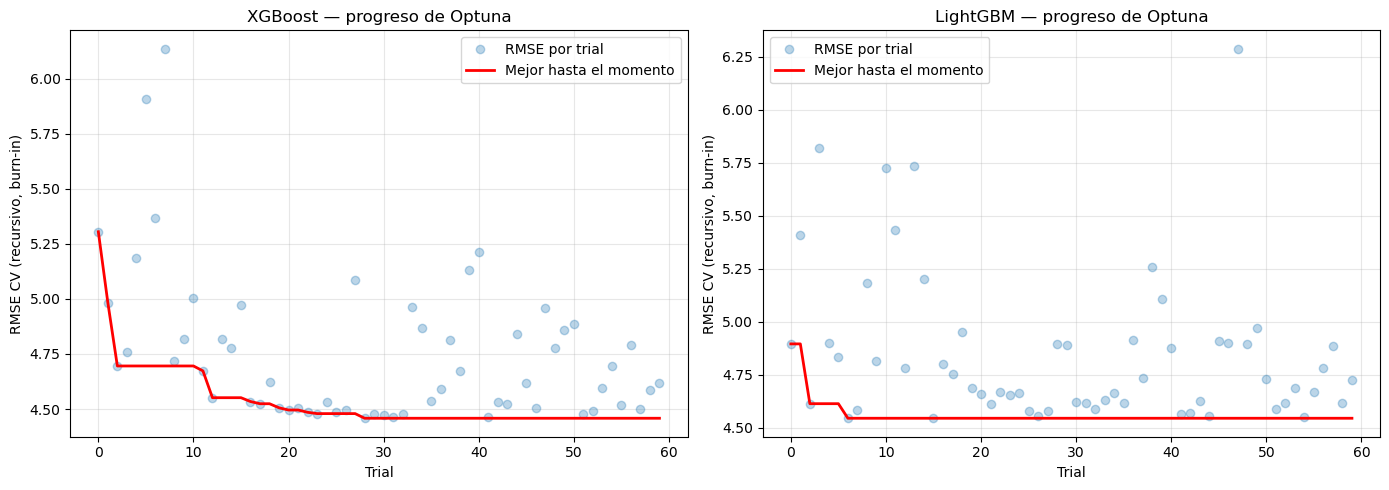

In [51]:
# Comparacion visual del progreso de ambos studies
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, study, nombre in zip(axes, [study_xgb, study_lgbm], ["XGBoost", "LightGBM"]):
    valores = [t.value for t in study.trials if t.value is not None]
    mejor_hasta_ahora = np.minimum.accumulate(valores)
    ax.plot(valores, "o", alpha=0.3, label="RMSE por trial")
    ax.plot(mejor_hasta_ahora, lw=2, color="red", label="Mejor hasta el momento")
    ax.set_title(f"{nombre} — progreso de Optuna")
    ax.set_xlabel("Trial")
    ax.set_ylabel("RMSE CV (recursivo, burn-in)")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "optuna_progreso.png", dpi=120, bbox_inches="tight")
plt.show()

In [52]:
# Guardar mejores hiperparametros + studies completos + config usada
mejores_params = {
    "xgboost": study_xgb.best_params,
    "lightgbm": study_lgbm.best_params,
    "config": {
        "min_burn_weeks": MIN_BURN_WEEKS,
        "test_weeks_por_fold": TEST_WEEKS_POR_FOLD,
        "n_folds_usados": len(folds),
        "fillna_value": FILLNA_VALUE,
        "drop_trend_features": DROP_TREND_FEATURES,
        "feature_cols": feature_cols,
        "rmse_cv_xgboost": study_xgb.best_value,
        "rmse_cv_lightgbm": study_lgbm.best_value,
    },
}
with open(OUT_DIR / "mejores_hiperparametros.json", "w") as f:
    json.dump(mejores_params, f, indent=2, ensure_ascii=False)

joblib.dump(study_xgb, OUT_DIR / "study_xgb.joblib")
joblib.dump(study_lgbm, OUT_DIR / "study_lgbm.joblib")

print(f"Guardado en: {OUT_DIR}")
print(json.dumps(mejores_params, indent=2, ensure_ascii=False))

Guardado en: /Users/guillermo/Downloads/TA_IA_Aplicada/Modelado/optuna
{
  "xgboost": {
    "n_estimators": 604,
    "max_depth": 3,
    "learning_rate": 0.018169391195341247,
    "min_child_weight": 5,
    "subsample": 0.9155444860229962,
    "colsample_bytree": 0.8256742685398336,
    "reg_alpha": 0.002616105131918576,
    "reg_lambda": 2.4854089905414054
  },
  "lightgbm": {
    "n_estimators": 539,
    "num_leaves": 119,
    "max_depth": 3,
    "learning_rate": 0.017987863473362915,
    "min_child_samples": 7,
    "subsample": 0.7301321323053057,
    "colsample_bytree": 0.7554709158757927,
    "reg_alpha": 0.007865589790890783,
    "reg_lambda": 0.7614139119869378
  },
  "config": {
    "min_burn_weeks": 52,
    "test_weeks_por_fold": 4,
    "n_folds_usados": 2,
    "fillna_value": null,
    "drop_trend_features": true,
    "feature_cols": [
      "semana_del_año_sin",
      "semana_del_año_cos",
      "mes_sin",
      "mes_cos",
      "semana_con_festivo",
      "count_lag_1w",
  

### Siguiente paso
`08_final_refit_eval.ipynb` toma `optuna/mejores_hiperparametros.json`, reentrena en todo `dev` y evalua recursivamente contra el holdout de 12 semanas, comparando contra los resultados actuales de `05_validacion_ts.ipynb`.
